# Instagram Fake / Spammer / Genuine Account Detection



## 1. Import Required Libraries


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings("ignore")


## 2. Load Training and Testing Dataset


In [3]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

train_df.head()


Train Shape: (576, 12)
Test Shape: (120, 12)


,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows,fake
0,1,0.27,0,0.0,0,53,0,0,32,1000,955,0
1,1,0.00,2,0.0,0,44,0,0,286,2740,533,0
2,1,0.10,2,0.0,0,0,0,1,13,159,98,0
3,1,0.00,1,0.0,0,82,0,0,679,414,651,0
4,1,0.00,2,0.0,0,0,0,1,6,151,126,0


## 3. Dataset Overview


In [4]:
train_df.info()
train_df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   profile pic           576 non-null    int64  
 1   nums/length username  576 non-null    float64
 2   fullname words        576 non-null    int64  
 3   nums/length fullname  576 non-null    float64
 4   name==username        576 non-null    int64  
 5   description length    576 non-null    int64  
 6   external URL          576 non-null    int64  
 7   private               576 non-null    int64  
 8   #posts                576 non-null    int64  
 9   #followers            576 non-null    int64  
 10  #follows              576 non-null    int64  
 11  fake                  576 non-null    int64  
dtypes: float64(2), int64(10)
memory usage: 54.1 KB


,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows,fake
count,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,5.760000e+02,576.000000,576.000000
mean,0.701389,0.163837,1.460069,0.036094,0.034722,22.623264,0.116319,0.381944,107.489583,8.530724e+04,508.381944,0.500000
std,0.458047,0.214096,1.052601,0.125121,0.183234,37.702987,0.320886,0.486285,402.034431,9.101485e+05,917.981239,0.500435
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
25%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.900000e+01,57.500000,0.000000
50%,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.505000e+02,229.500000,0.500000
75%,1.000000,0.310000,2.000000,0.000000,0.000000,34.000000,0.000000,1.000000,81.500000,7.160000e+02,589.500000,1.000000
max,1.000000,0.920000,12.000000,1.000000,1.000000,150.000000,1.000000,1.000000,7389.000000,1.533854e+07,7500.000000,1.000000


## 4. Checking Missing Values


In [5]:
print(train_df.isnull().sum())
print(test_df.isnull().sum())


profile pic             0
nums/length username    0
fullname words          0
nums/length fullname    0
name==username          0
description length      0
external URL            0
private                 0
#posts                  0
#followers              0
#follows                0
fake                    0
dtype: int64
profile pic             0
nums/length username    0
fullname words          0
nums/length fullname    0
name==username          0
description length      0
external URL            0
private                 0
#posts                  0
#followers              0
#follows                0
fake                    0
dtype: int64


## 5. Account Type Distribution


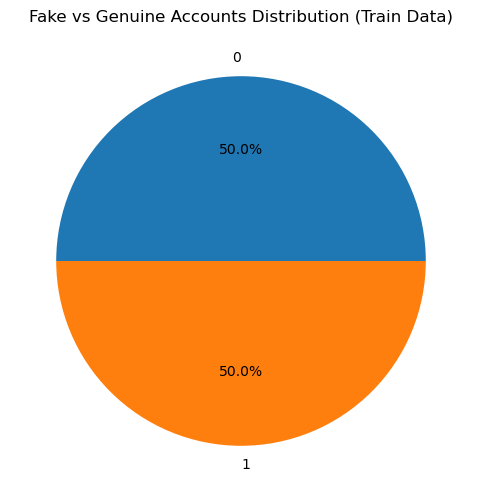

In [7]:
plt.figure(figsize=(6,6))
train_df['fake'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Fake vs Genuine Accounts Distribution (Train Data)")
plt.ylabel("")
plt.show()


## 6. Correlation Heatmap


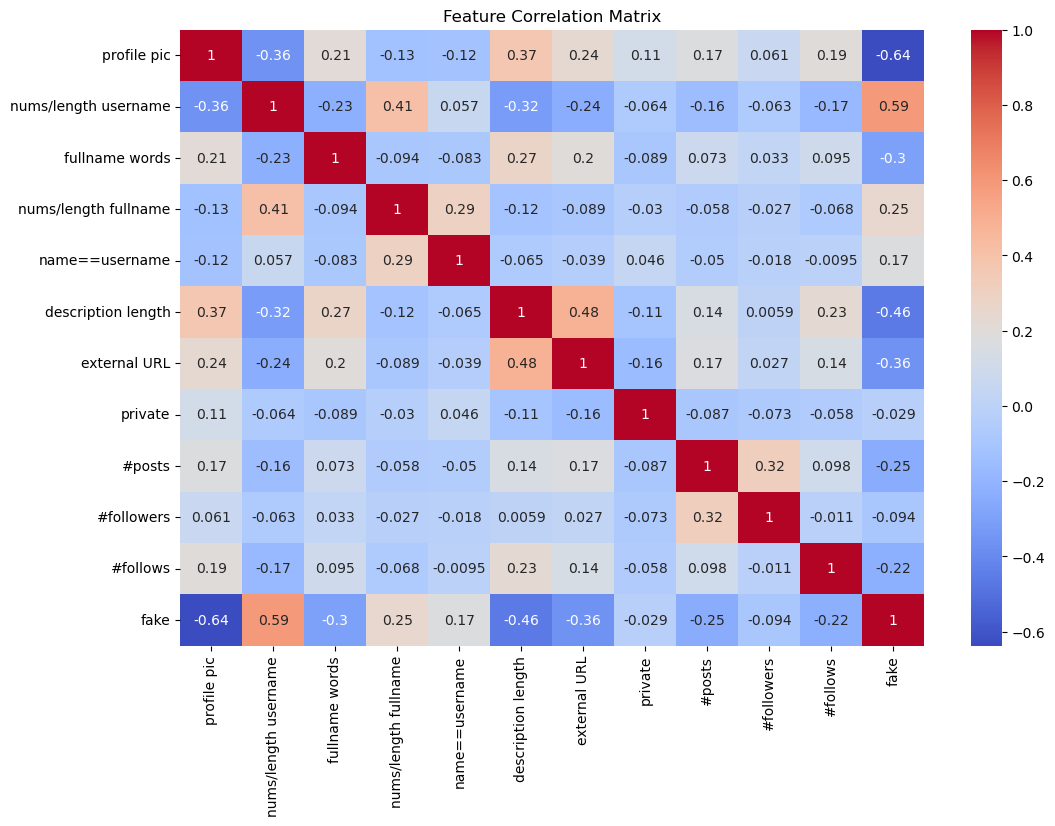

In [12]:
plt.figure(figsize=(12,8))
sns.heatmap(train_df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()


## 7. Splitting Features and Target Variable


In [10]:
X_train = train_df.drop("fake", axis=1)
y_train = train_df["fake"]

X_test = test_df.drop("fake", axis=1)
y_test = test_df["fake"]


## 8. Model Training - Random Forest


In [11]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

model.fit(X_train, y_train)


,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 9. Model Prediction


In [13]:
y_pred = model.predict(X_test)


## 10. Model Evaluation


In [14]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.9166666666666666

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.93      0.92        60
           1       0.93      0.90      0.92        60

    accuracy                           0.92       120
   macro avg       0.92      0.92      0.92       120
weighted avg       0.92      0.92      0.92       120



## 11. Confusion Matrix


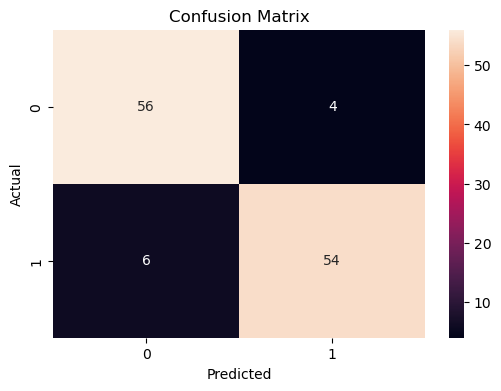

In [15]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True,
            fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## 12. Feature Importance Analysis


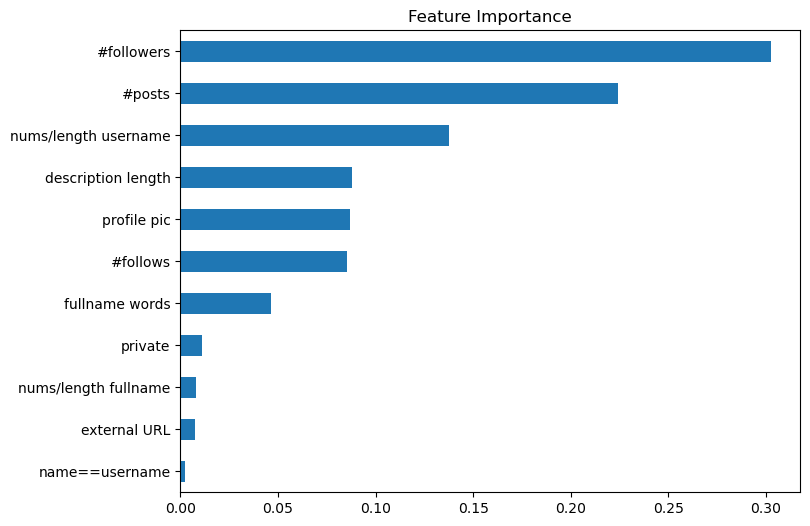

In [16]:
importance = pd.Series(model.feature_importances_, index=X_train.columns)
importance = importance.sort_values()

plt.figure(figsize=(8,6))
importance.plot(kind='barh')
plt.title("Feature Importance")
plt.show()


## Followers Distribution by Account Type


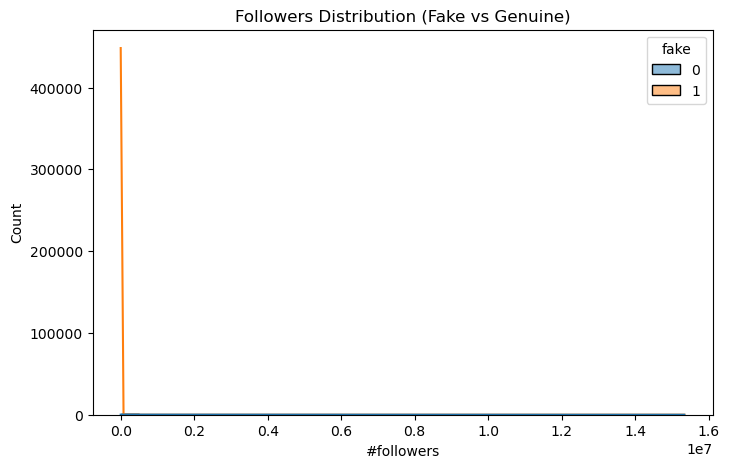

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(data=train_df, x="#followers", hue="fake", bins=30, kde=True)
plt.title("Followers Distribution (Fake vs Genuine)")
plt.show()


## Following Distribution by Account Type


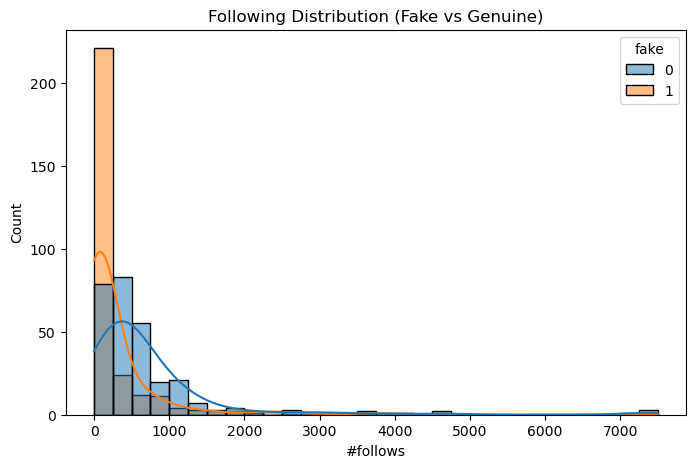

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(data=train_df, x="#follows", hue="fake", bins=30, kde=True)
plt.title("Following Distribution (Fake vs Genuine)")
plt.show()


## Posts Count Comparison


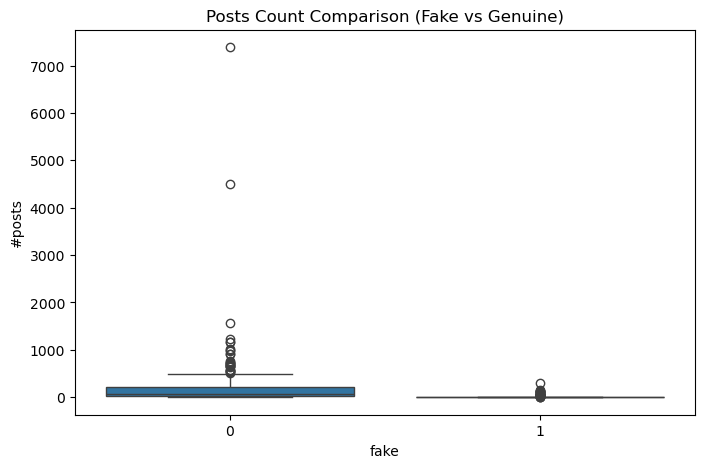

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(x="fake", y="#posts", data=train_df)
plt.title("Posts Count Comparison (Fake vs Genuine)")
plt.show()


This shows:
• Fake accounts usually have fewer posts
• Genuine accounts tend to have higher activity

## Engagement Ratio Analysis


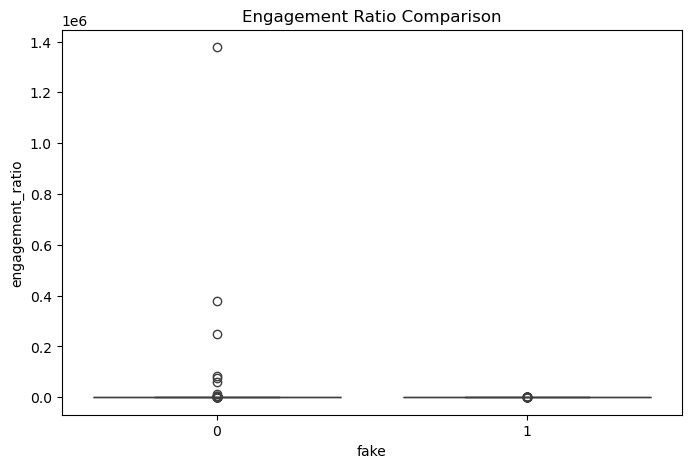

In [23]:
# Create Engagement Ratio
train_df["engagement_ratio"] = train_df["#followers"] / (train_df["#follows"] + 1)

plt.figure(figsize=(8,5))
sns.boxplot(x="fake", y="engagement_ratio", data=train_df)
plt.title("Engagement Ratio Comparison")
plt.show()


## Multiple Feature Distribution


train_df.hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()


## 13. Instagram Risk Score System


In [17]:
# Probability of being fake
test_df["Risk_Score"] = model.predict_proba(X_test)[:,1] * 100

test_df[["Risk_Score"]].head()


,Risk_Score
0,27.0
1,41.5
2,0.5
3,6.0
4,58.0


## 14. Risk Level Categorization


In [18]:
def risk_level(score):
    if score < 30:
        return "Low Risk"
    elif score < 70:
        return "Medium Risk"
    else:
        return "High Risk"

test_df["Risk_Level"] = test_df["Risk_Score"].apply(risk_level)

test_df["Risk_Level"].value_counts()


Risk_Level
Low Risk       53
High Risk      53
Medium Risk    14
Name: count, dtype: int64

## 15. Risk Category Distribution


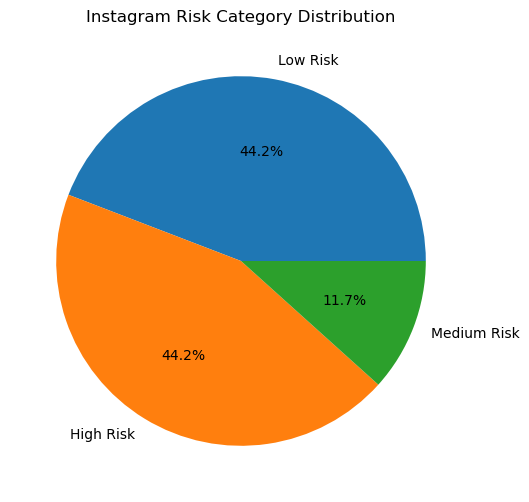

In [19]:
plt.figure(figsize=(6,6))
test_df["Risk_Level"].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Instagram Risk Category Distribution")
plt.ylabel("")
plt.show()


# Conclusion

The Instagram Fake Account Detection project successfully implemented a Random Forest Machine Learning model to classify fake and genuine accounts.

Key Achievements:

• Used separate train and test datasets as per project guidelines.
• Performed Exploratory Data Analysis and Feature Correlation.
• Achieved strong classification accuracy.
• Built a Risk Scoring System using probability outputs.
• Categorized accounts into Low, Medium, and High Risk groups.

Business Impact:

This model can help:
• Social media platforms detect fake users
• Digital marketers verify influencer authenticity
• Reduce spam and fraudulent activity
• Improve cybersecurity monitoring

The project demonstrates practical Machine Learning application in real-world fraud detection systems and is internship-ready for production-level enhancement.
